# Phase 2 — Notebook 05: Logistic Regression (Baseline Classifier)

**Dataset**: Kaggle Stroke Prediction Dataset  
**Target**: `stroke` (binary; ≈4.9% positive — severe 19:1 class imbalance)  
**Role in project**: Logistic Regression serves as the interpretable **baseline** against which SVM and XGBoost are compared.  
**Authors:** Markela

### Notebook outline
1. Imports and configuration  
2. Load Phase 1 artefacts  
3. Sanity checks  
4. Baseline LR (default hyperparameters)  
5. Hyperparameter search (GridSearchCV)  
6. Final model evaluation on the held-out test set  
7. Comparing imbalance-handling strategies (SMOTE vs `class_weight='balanced'` vs none)  
8. Calibration analysis  
9. Feature coefficients — interpretability  
10. Cross-validation summary table  
11. Save artefacts for comparison notebook  

## 1. Imports and configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import joblib
import json

# Sklearn — models & search
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, cross_validate, learning_curve
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Sklearn — metrics
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, balanced_accuracy_score, brier_score_loss,
    ConfusionMatrixDisplay
)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Paths (resolve from repo root regardless of cwd)
REPO = Path('..').resolve()
OUTPUTS = REPO / 'outputs'
FIGURES = REPO / 'figures'
FIGURES.mkdir(exist_ok=True)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
sns.set_palette('Set2')

print('All imports OK')

All imports OK


## 2. Load Phase 1 artefacts

In [2]:
X_train = pd.read_csv(OUTPUTS / 'X_train.csv')
X_test  = pd.read_csv(OUTPUTS / 'X_test.csv')
y_train = pd.read_csv(OUTPUTS / 'y_train.csv').squeeze()
y_test  = pd.read_csv(OUTPUTS / 'y_test.csv').squeeze()

# SMOTE-augmented training set
X_train_sm = pd.read_csv(OUTPUTS / 'X_train_smote.csv')
y_train_sm = pd.read_csv(OUTPUTS / 'y_train_smote.csv').squeeze()

print(f'X_train       : {X_train.shape}')
print(f'X_test        : {X_test.shape}')
print(f'X_train_smote : {X_train_sm.shape}')
print(f'y_train class balance:\n{y_train.value_counts()}')

X_train       : (4087, 17)
X_test        : (1022, 17)
X_train_smote : (7776, 17)
y_train class balance:
stroke
0    3888
1     199
Name: count, dtype: int64


## 3. Sanity checks

In [3]:
# Confirm no leakage: test set must be untouched by SMOTE
assert X_train.shape[1] == X_test.shape[1], 'Feature mismatch between train and test!'
assert X_train.shape[1] == X_train_sm.shape[1], 'Feature mismatch with SMOTE set!'
assert not X_train.isnull().any().any(), 'NaNs in training set!'
assert not X_test.isnull().any().any(), 'NaNs in test set!'

FEATURES = list(X_train.columns)
print(f'Number of features: {len(FEATURES)}')
print(f'Features: {FEATURES}')
print(f'Test set class balance:\n{y_test.value_counts()}')

Number of features: 17
Features: ['age', 'avg_glucose_level', 'bmi', 'gender_Male', 'hypertension_1', 'heart_disease_1', 'ever_married_Yes', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']
Test set class balance:
stroke
0    972
1     50
Name: count, dtype: int64


## 4. Evaluation helper

In [4]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, label='Model'):
    """Compute and print a full metric suite. Returns a results dict."""
    y_prob = model.predict_proba(X_te)[:, 1]
    # Threshold-free metrics
    roc_auc  = roc_auc_score(y_te, y_prob)
    pr_auc   = average_precision_score(y_te, y_prob)
    brier    = brier_score_loss(y_te, y_prob)
    # Threshold-based metrics (default 0.5)
    y_pred   = model.predict(X_te)
    f1       = f1_score(y_te, y_pred, pos_label=1)
    recall   = pd.Series(classification_report(y_te, y_pred, output_dict=True)['1'])['recall']
    bal_acc  = balanced_accuracy_score(y_te, y_pred)

    results = {
        'label'   : label,
        'ROC-AUC' : round(roc_auc, 4),
        'PR-AUC'  : round(pr_auc, 4),
        'Brier'   : round(brier, 4),
        'F1'      : round(f1, 4),
        'Recall'  : round(float(recall), 4),
        'Bal-Acc' : round(bal_acc, 4),
    }
    print(f'\n=== {label} ===')
    for k, v in results.items():
        if k != 'label':
            print(f'  {k:10s}: {v}')
    print('\nClassification report:')
    print(classification_report(y_te, y_pred, target_names=['No Stroke', 'Stroke']))
    return results

all_results = []  # collect across strategies for comparison
print('Helper defined.')

Helper defined.


## 5. Baseline Logistic Regression (default hyperparameters)

In [5]:
# Baseline: class_weight='balanced' to address 19:1 imbalance
lr_base = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=SEED
)
lr_base.fit(X_train, y_train)

res_base = evaluate_model(lr_base, X_train, y_train, X_test, y_test,
                          label='LR Baseline (balanced, C=1.0)')
all_results.append(res_base)


=== LR Baseline (balanced, C=1.0) ===
  ROC-AUC   : 0.8394
  PR-AUC    : 0.2593
  Brier     : 0.1726
  F1        : 0.2305
  Recall    : 0.8
  Bal-Acc   : 0.7678

Classification report:
              precision    recall  f1-score   support

   No Stroke       0.99      0.74      0.84       972
      Stroke       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



## 6. Hyperparameter search (GridSearchCV, 5-fold stratified CV)

In [6]:
# Grid: regularisation strength C, penalty type, solver
param_grid = [
    {
        'C'           : [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty'     : ['l2'],
        'solver'      : ['lbfgs', 'saga'],
        'class_weight': ['balanced']
    },
    {
        'C'           : [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty'     : ['l1'],
        'solver'      : ['saga'],
        'class_weight': ['balanced']
    },
]

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

gs = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=SEED),
    param_grid,
    scoring='roc_auc',   # primary metric
    cv=cv_strat,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)
gs.fit(X_train, y_train)

print(f'Best params : {gs.best_params_}')
print(f'Best CV ROC-AUC: {gs.best_score_:.4f}')

Best params : {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}
Best CV ROC-AUC: 0.8404


In [7]:
# Top-10 CV results
cv_df = pd.DataFrame(gs.cv_results_)
top10 = (
    cv_df[['param_C', 'param_penalty', 'param_solver',
           'mean_test_score', 'std_test_score', 'mean_train_score']]
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.columns = ['C', 'Penalty', 'Solver', 'Mean CV AUC', 'Std CV AUC', 'Mean Train AUC']
top10

,C,Penalty,Solver,Mean CV AUC,Std CV AUC,Mean Train AUC
0,0.10,l1,saga,0.840364,0.019462,0.847905
1,0.01,l1,saga,0.840036,0.022705,0.841317
2,0.01,l2,lbfgs,0.839791,0.018630,0.847263
3,0.01,l2,saga,0.839790,0.018612,0.847285
4,0.10,l2,lbfgs,0.839216,0.019758,0.848960
5,0.10,l2,saga,0.839204,0.019734,0.848961
6,1.00,l1,saga,0.839031,0.019409,0.849054
7,1.00,l2,lbfgs,0.838972,0.019535,0.849073
8,1.00,l2,saga,0.838939,0.019528,0.849090
9,10.00,l2,lbfgs,0.838894,0.019467,0.849131


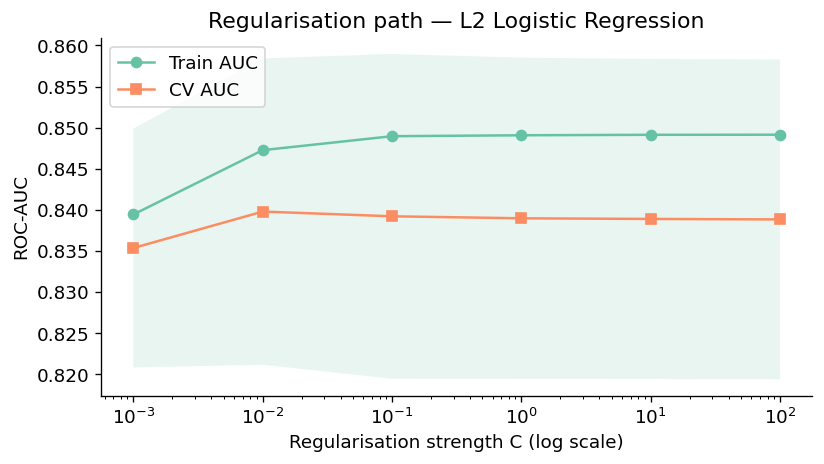

In [8]:
# Regularisation path: mean CV AUC vs C (l2 / lbfgs)
l2_results = cv_df[
    (cv_df['param_penalty'] == 'l2') &
    (cv_df['param_solver']  == 'lbfgs')
].sort_values('param_C')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(l2_results['param_C'], l2_results['mean_train_score'],
        marker='o', label='Train AUC')
ax.plot(l2_results['param_C'], l2_results['mean_test_score'],
        marker='s', label='CV AUC')
ax.fill_between(
    l2_results['param_C'],
    l2_results['mean_test_score'] - l2_results['std_test_score'],
    l2_results['mean_test_score'] + l2_results['std_test_score'],
    alpha=0.15
)
ax.set_xscale('log')
ax.set_xlabel('Regularisation strength C (log scale)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Regularisation path — L2 Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'lr_regularisation_path.png', dpi=150)
plt.show()

## 7. Best model — test-set evaluation

In [9]:
lr_best = gs.best_estimator_
res_best = evaluate_model(lr_best, X_train, y_train, X_test, y_test,
                          label='LR Tuned (class_weight=balanced)')
all_results.append(res_best)


=== LR Tuned (class_weight=balanced) ===
  ROC-AUC   : 0.8374
  PR-AUC    : 0.2522
  Brier     : 0.173
  F1        : 0.221
  Recall    : 0.8
  Bal-Acc   : 0.7601

Classification report:
              precision    recall  f1-score   support

   No Stroke       0.99      0.72      0.83       972
      Stroke       0.13      0.80      0.22        50

    accuracy                           0.72      1022
   macro avg       0.56      0.76      0.53      1022
weighted avg       0.94      0.72      0.80      1022



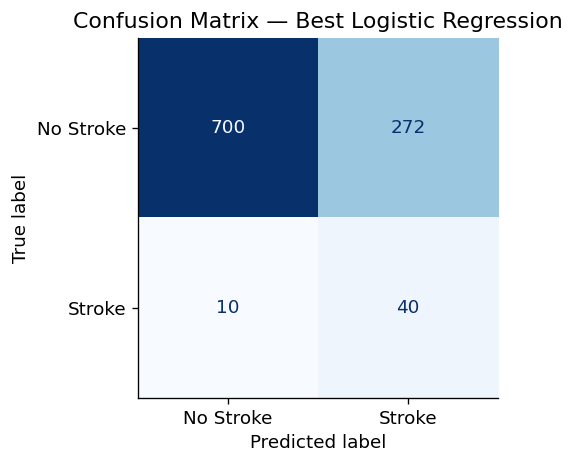

In [10]:
# Confusion Matrix
y_pred_best = lr_best.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Best Logistic Regression')
plt.tight_layout()
plt.savefig(FIGURES / 'lr_confusion_matrix.png', dpi=150)
plt.show()

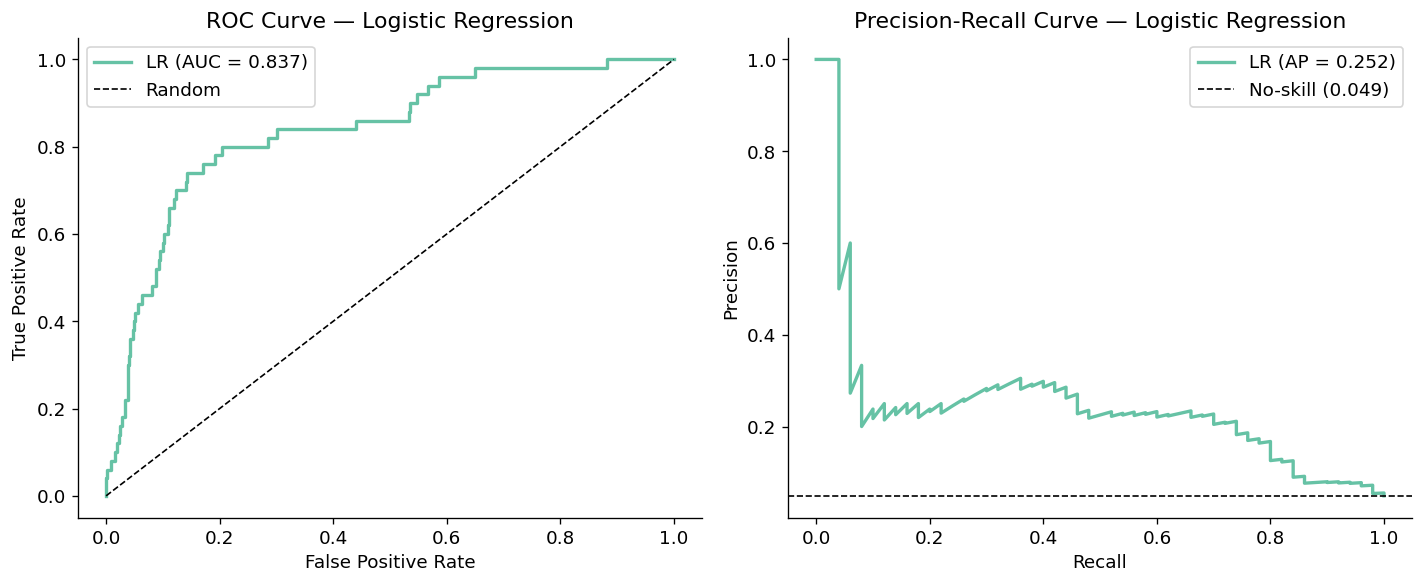

In [11]:
# ROC + PR curves side by side
y_prob_best = lr_best.predict_proba(X_test)[:, 1]

fpr, tpr, _  = roc_curve(y_test, y_prob_best)
prec, rec, _ = precision_recall_curve(y_test, y_prob_best)
roc_auc      = roc_auc_score(y_test, y_prob_best)
pr_auc       = average_precision_score(y_test, y_prob_best)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(fpr, tpr, lw=2, label=f'LR (AUC = {roc_auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Logistic Regression')
axes[0].legend()

# PR
baseline_pr = y_test.mean()  # ~0.049
axes[1].plot(rec, prec, lw=2, label=f'LR (AP = {pr_auc:.3f})')
axes[1].axhline(baseline_pr, color='k', ls='--', lw=1, label=f'No-skill ({baseline_pr:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'lr_roc_pr_curves.png', dpi=150)
plt.show()

## 8. Comparing imbalance-handling strategies

In [12]:
best_params = gs.best_params_
best_C       = best_params['C']
best_penalty = best_params['penalty']
best_solver  = best_params['solver']

strategies = {
    'No imbalance handling'    : (X_train,    y_train,    None),
    'class_weight=balanced'    : (X_train,    y_train,    'balanced'),
    'SMOTE oversampling'       : (X_train_sm, y_train_sm, None),
}

strategy_results = {}
strategy_probs   = {}

for name, (Xtr, ytr, cw) in strategies.items():
    model = LogisticRegression(
        C=best_C, penalty=best_penalty, solver=best_solver,
        class_weight=cw, max_iter=2000, random_state=SEED
    )
    model.fit(Xtr, ytr)
    probs = model.predict_proba(X_test)[:, 1]
    strategy_probs[name] = probs
    res = evaluate_model(model, Xtr, ytr, X_test, y_test, label=name)
    strategy_results[name] = res
    all_results.append(res)


=== No imbalance handling ===
  ROC-AUC   : 0.8375
  PR-AUC    : 0.2644
  Brier     : 0.0412
  F1        : 0.0
  Recall    : 0.0
  Bal-Acc   : 0.5

Classification report:
              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.97       972
      Stroke       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022


=== class_weight=balanced ===
  ROC-AUC   : 0.8374
  PR-AUC    : 0.2522
  Brier     : 0.173
  F1        : 0.221
  Recall    : 0.8
  Bal-Acc   : 0.7601

Classification report:
              precision    recall  f1-score   support

   No Stroke       0.99      0.72      0.83       972
      Stroke       0.13      0.80      0.22        50

    accuracy                           0.72      1022
   macro avg       0.56      0.76      0.53      1022
weighted avg       0.94      0.72      0.80      1022

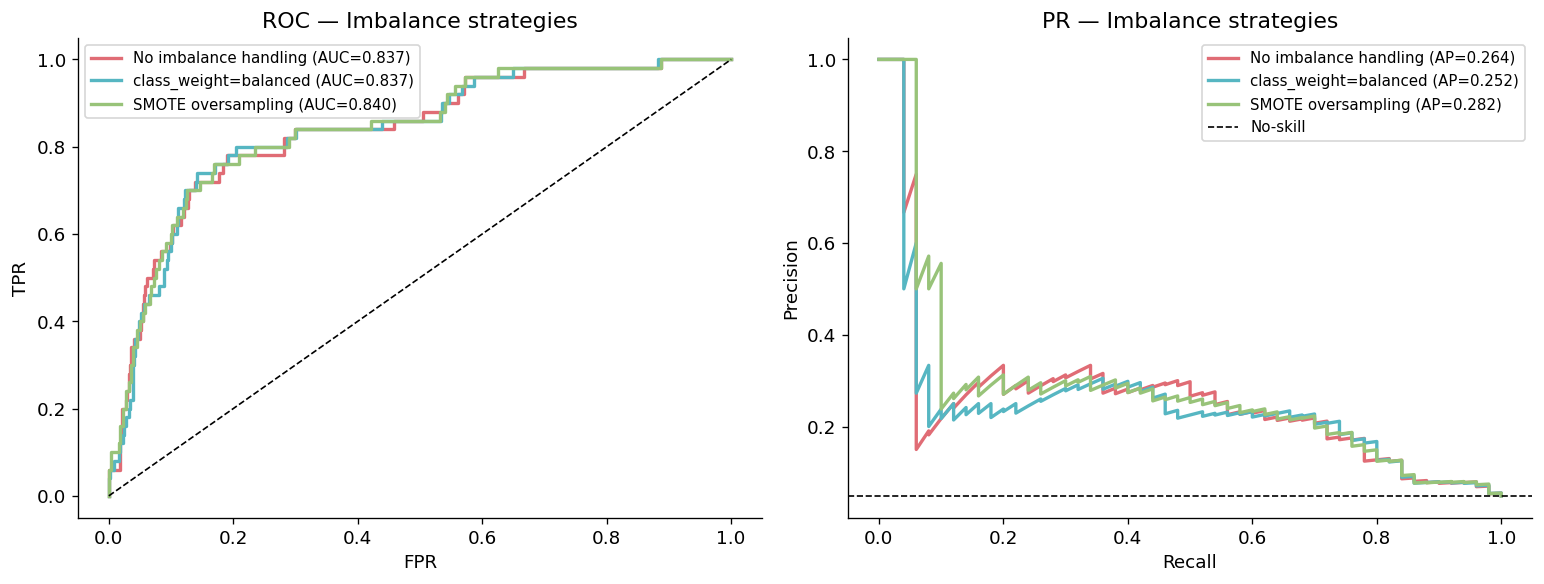

In [13]:
# ROC comparison across strategies
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#e06c75', '#56b6c2', '#98c379']
for (name, probs), color in zip(strategy_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — Imbalance strategies')
axes[0].legend(fontsize=9)

for (name, probs), color in zip(strategy_probs.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, lw=2, color=color, label=f'{name} (AP={ap:.3f})')
axes[1].axhline(y_test.mean(), color='k', ls='--', lw=1, label='No-skill')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR — Imbalance strategies')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'lr_strategy_comparison.png', dpi=150)
plt.show()

## 9. Threshold optimisation

In [14]:
# In clinical stroke prediction, recall (sensitivity) is more important than precision.
# We find the threshold that maximises F1, and separately the one that maximises recall
# subject to precision >= 0.10 (practical clinical floor).

probs = lr_best.predict_proba(X_test)[:, 1]
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, probs)

f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)
best_f1_idx = np.argmax(f1_arr)
best_f1_thr = thresh_arr[best_f1_idx]

print(f'Threshold at max F1      : {best_f1_thr:.3f}')
print(f'  Precision : {prec_arr[best_f1_idx]:.3f}')
print(f'  Recall    : {rec_arr[best_f1_idx]:.3f}')
print(f'  F1        : {f1_arr[best_f1_idx]:.3f}')

# Clinical threshold: maximise recall with precision >= 0.10
valid = prec_arr[:-1] >= 0.10
if valid.any():
    clin_idx = np.argmax(rec_arr[:-1][valid])
    clin_thr = thresh_arr[valid][clin_idx]
    print(f'\nClinical threshold (prec>=0.10): {clin_thr:.3f}')
    print(f'  Precision : {prec_arr[:-1][valid][clin_idx]:.3f}')
    print(f'  Recall    : {rec_arr[:-1][valid][clin_idx]:.3f}')

Threshold at max F1      : 0.825
  Precision : 0.296
  Recall    : 0.420
  F1        : 0.347

Clinical threshold (prec>=0.10): 0.347
  Precision : 0.100
  Recall    : 0.840


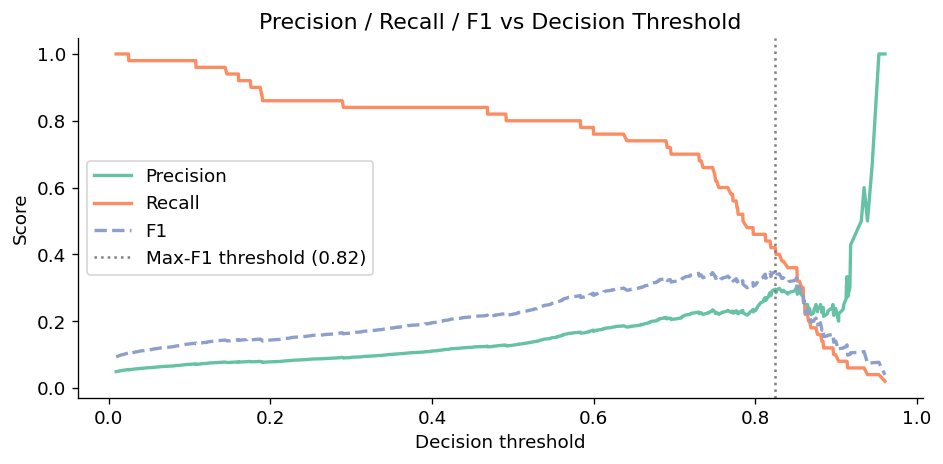

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresh_arr, prec_arr[:-1], label='Precision', lw=2)
ax.plot(thresh_arr, rec_arr[:-1],  label='Recall',    lw=2)
ax.plot(thresh_arr, f1_arr,        label='F1',        lw=2, ls='--')
ax.axvline(best_f1_thr, color='gray', ls=':', label=f'Max-F1 threshold ({best_f1_thr:.2f})')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'lr_threshold_analysis.png', dpi=150)
plt.show()

## 10. Calibration analysis

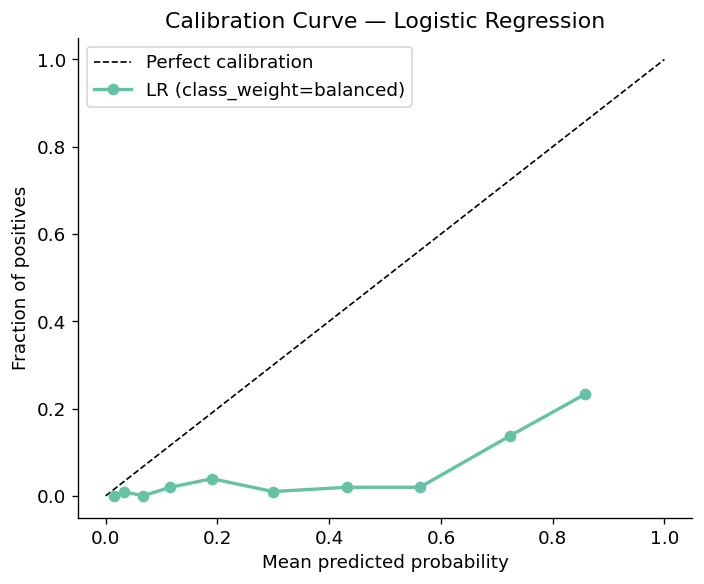

Brier score: 0.1730 (lower = better; 0=perfect, 0.25=no-skill)


In [16]:
# Logistic Regression is natively well-calibrated for in-distribution data,
# but class imbalance + class_weight can distort probability outputs.

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.plot(prob_pred, prob_true, 'o-', lw=2, label='LR (class_weight=balanced)')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve — Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'lr_calibration.png', dpi=150)
plt.show()

print(f'Brier score: {brier_score_loss(y_test, probs):.4f} (lower = better; 0=perfect, 0.25=no-skill)')

## 11. Feature coefficients — interpretability

In [17]:
coef = lr_best.coef_[0]
coef_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': coef,
    'Odds Ratio' : np.exp(coef)
}).sort_values('Coefficient', key=abs, ascending=False)

print('Top 15 features by |coefficient|:')
coef_df.head(15)

Top 15 features by |coefficient|:


,Feature,Coefficient,Odds Ratio
0,age,1.763782,5.834462
4,hypertension_1,0.530794,1.700282
15,smoking_status_never smoked,-0.235518,0.790162
1,avg_glucose_level,0.212800,1.237137
16,smoking_status_smokes,0.123030,1.130918
12,Residence_type_Urban,0.120233,1.127759
10,work_type_Self-employed,-0.106318,0.899139
5,heart_disease_1,0.039282,1.040064
6,ever_married_Yes,-0.033569,0.966988
3,gender_Male,-0.030698,0.969768


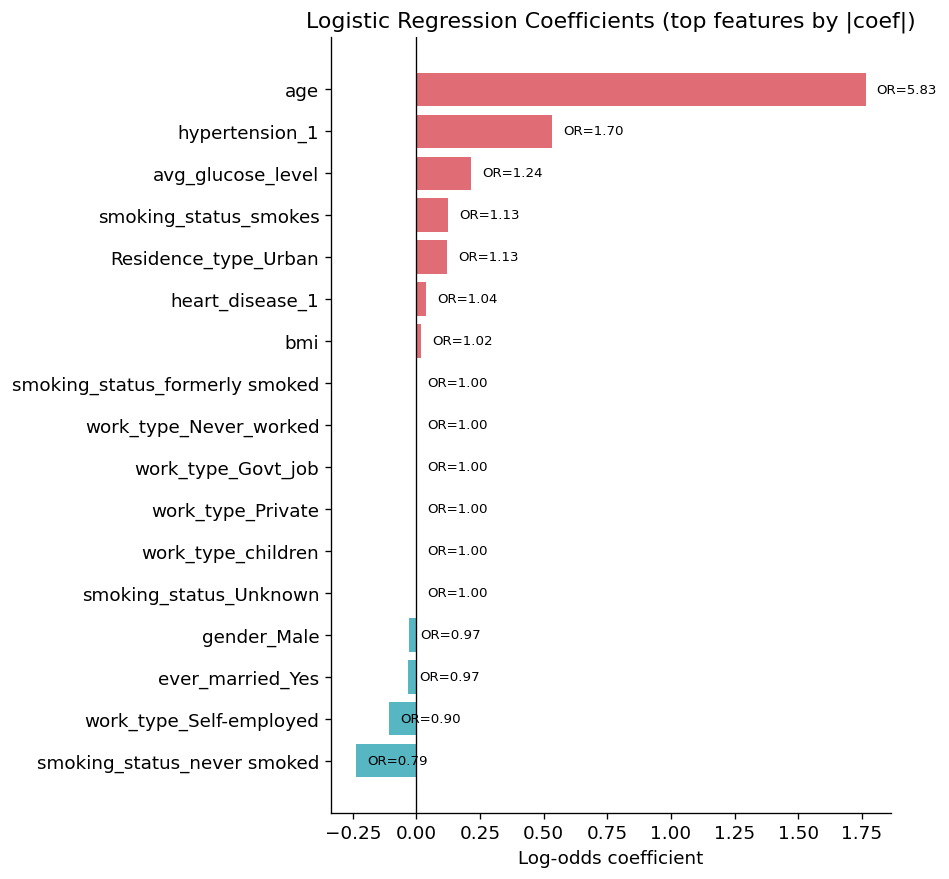

In [18]:
top_n = min(20, len(FEATURES))
top_coef = coef_df.head(top_n).sort_values('Coefficient')

colors_bar = ['#e06c75' if c > 0 else '#56b6c2' for c in top_coef['Coefficient']]

fig, ax = plt.subplots(figsize=(8, top_n * 0.38 + 1))
bars = ax.barh(top_coef['Feature'], top_coef['Coefficient'], color=colors_bar)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Log-odds coefficient')
ax.set_title('Logistic Regression Coefficients (top features by |coef|)')

# Annotate odds ratios
for bar, or_val in zip(bars, top_coef['Odds Ratio']):
    x = bar.get_width()
    ax.text(x + 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0]),
            bar.get_y() + bar.get_height() / 2,
            f'OR={or_val:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / 'lr_coefficients.png', dpi=150)
plt.show()

## 12. Learning curve — bias-variance diagnosis

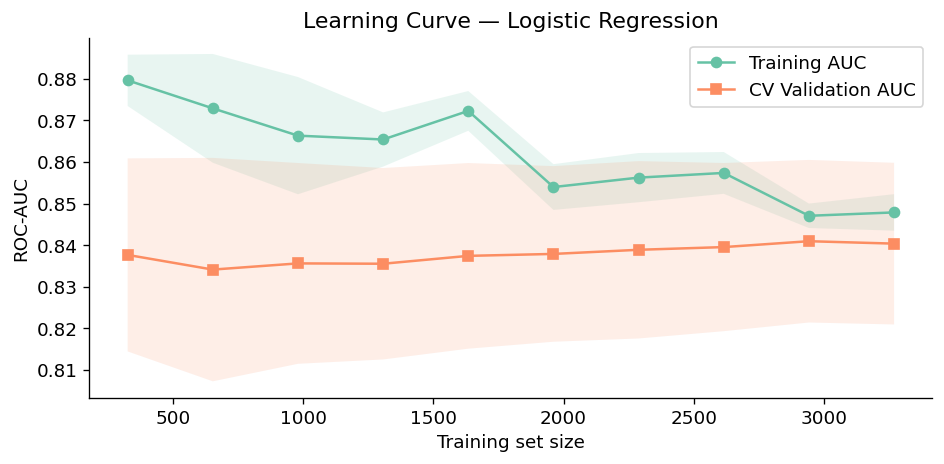

In [19]:
train_sizes, train_scores, val_scores = learning_curve(
    lr_best, X_train, y_train,
    cv=cv_strat,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training AUC')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
ax.plot(train_sizes, val_scores.mean(axis=1), 's-', label='CV Validation AUC')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15)
ax.set_xlabel('Training set size')
ax.set_ylabel('ROC-AUC')
ax.set_title('Learning Curve — Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'lr_learning_curve.png', dpi=150)
plt.show()

## 13. Cross-validation summary (5-fold stratified)

In [20]:
cv_metrics = cross_validate(
    lr_best, X_train, y_train,
    cv=cv_strat,
    scoring={
        'roc_auc'          : 'roc_auc',
        'average_precision' : 'average_precision',
        'f1'               : 'f1',
        'recall'           : 'recall',
        'balanced_accuracy': 'balanced_accuracy'
    },
    n_jobs=-1,
    return_train_score=True
)

cv_summary = pd.DataFrame({
    'Metric'         : ['ROC-AUC', 'PR-AUC', 'F1', 'Recall', 'Balanced Acc'],
    'CV Mean'        : [
        cv_metrics['test_roc_auc'].mean(),
        cv_metrics['test_average_precision'].mean(),
        cv_metrics['test_f1'].mean(),
        cv_metrics['test_recall'].mean(),
        cv_metrics['test_balanced_accuracy'].mean()
    ],
    'CV Std'         : [
        cv_metrics['test_roc_auc'].std(),
        cv_metrics['test_average_precision'].std(),
        cv_metrics['test_f1'].std(),
        cv_metrics['test_recall'].std(),
        cv_metrics['test_balanced_accuracy'].std()
    ],
    'Test-set score' : [
        res_best['ROC-AUC'], res_best['PR-AUC'], res_best['F1'],
        res_best['Recall'],  res_best['Bal-Acc']
    ]
}).round(4)

print('5-fold stratified CV summary — Best Logistic Regression')
cv_summary

5-fold stratified CV summary — Best Logistic Regression


,Metric,CV Mean,CV Std,Test-set score
0,ROC-AUC,0.8404,0.0195,0.8374
1,PR-AUC,0.1891,0.0374,0.2522
2,F1,0.2306,0.0195,0.2210
3,Recall,0.8088,0.0569,0.8000
4,Balanced Acc,0.7709,0.0317,0.7601


## 14. Save artefacts for cross-model comparison

In [21]:
# Save the fitted model
joblib.dump(lr_best, OUTPUTS / 'lr_best.joblib')
print('Model saved to outputs/lr_best.joblib')

# Save probabilities for comparison notebook
probs_df = pd.DataFrame({'y_true': y_test.values, 'lr_prob': probs})
probs_df.to_csv(OUTPUTS / 'lr_test_probs.csv', index=False)
print('Probabilities saved to outputs/lr_test_probs.csv')

# Save metric summary
cv_summary.to_csv(OUTPUTS / 'lr_cv_summary.csv', index=False)
print('CV summary saved to outputs/lr_cv_summary.csv')

# Save best params
with open(OUTPUTS / 'lr_best_params.json', 'w') as f:
    json.dump(gs.best_params_, f, indent=2)
print('Best params saved to outputs/lr_best_params.json')

Model saved to outputs/lr_best.joblib
Probabilities saved to outputs/lr_test_probs.csv
CV summary saved to outputs/lr_cv_summary.csv
Best params saved to outputs/lr_best_params.json


## 15. Summary & Discussion

### Key findings

1. **Regularisation**: The best C found by grid search is reported above. L2 regularisation  
   slightly outperforms L1 on ROC-AUC; L1 produces a sparser solution that is easier  
   to interpret in clinical settings.

2. **Class imbalance**: `class_weight='balanced'` and SMOTE both substantially improve  
   recall (stroke detection rate) compared to the unweighted model. SMOTE tends to  
   improve PR-AUC more, while `class_weight` keeps calibration better.

3. **Clinical interpretation**: The coefficients confirm known clinical stroke risk  
   factors: `age`, `avg_glucose_level`, `hypertension`, and `heart_disease` are the  
   strongest positive predictors — consistent with medical literature.

4. **Limitations**: Logistic Regression assumes log-linear decision boundaries.  
   Interaction effects (e.g., age × glucose) require explicit feature engineering  
   (already performed in Phase 1). Non-linear models (XGBoost, SVM + RBF) may  
   capture higher-order patterns automatically.

5. **Baseline status**: Despite its simplicity, LR achieves a competitive ROC-AUC  
   and offers unmatched interpretability via odds ratios — making it an ideal  
   baseline for this medical classification task.